# <b>Log(P) Prediction with a CNN</b>

### Import Libraries

In [24]:
### Maths and Data-Handling
import numpy as np
from copy import deepcopy
import pandas as pd
from pysmilesutils.tokenize import *
from pysmilesutils.analyze import analyze_smiles_tokens

### Visualisation
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

### Scikit-learn
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

### PyTorch
import torch
from torch import nn

## 1 | Load Data and Tokenize with PySMILESutils

In [25]:
# load data as pandas.DataFrame object
logPdata = pd.read_csv('logP_dataset.csv', names=['SMILES', 'ClogP'])

print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)

log(P) DataFrame columns:  Index(['SMILES', 'ClogP'], dtype='object')
log(P) DataFrame shape:  (14610, 2)


In [26]:
# tokenize SMILES strings
smiles_list = logPdata['SMILES'].to_list()

tokenizer = SMILESTokenizer(smiles=smiles_list)


# add to dataframe
logPdata['Tokenize'] = tokenizer(smiles_list)

print("Tokenizer vocabulary dictionary:", tokenizer.vocabulary)
print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)

Tokenizer vocabulary dictionary: {' ': 0, '^': 1, '&': 2, '?': 3, 'C': 4, '[': 5, '@': 6, 'H': 7, ']': 8, '(': 9, ')': 10, 'l': 11, '=': 12, 'B': 13, 'r': 14, 'N': 15, 'O': 16, '1': 17, '3': 18, '2': 19, 'P': 20, 'F': 21, 'I': 22, '+': 23, 'S': 24, '-': 25, '/': 26, '\\': 27, '.': 28, '8': 29, '#': 30, '4': 31, '9': 32, '5': 33, '7': 34, '0': 35, '6': 36}
log(P) DataFrame columns:  Index(['SMILES', 'ClogP', 'Tokenize'], dtype='object')
log(P) DataFrame shape:  (14610, 3)


Tutorial: https://www.geeksforgeeks.org/deep-learning/building-a-convolutional-neural-network-using-pytorch

In [27]:
# check length of each tokenized SMILES string
# store in 'tokens_len' list
tokens_len = list()

for tokens in logPdata['Tokenize']:
    entry_length = tokens.size()[0]
    tokens_len.append(entry_length)


# add to dataframe
logPdata['Tokenized Length'] = tokens_len

print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)
print('Maximum Token Length: ', max(tokens_len))

log(P) DataFrame columns:  Index(['SMILES', 'ClogP', 'Tokenize', 'Tokenized Length'], dtype='object')
log(P) DataFrame shape:  (14610, 4)
Maximum Token Length:  140


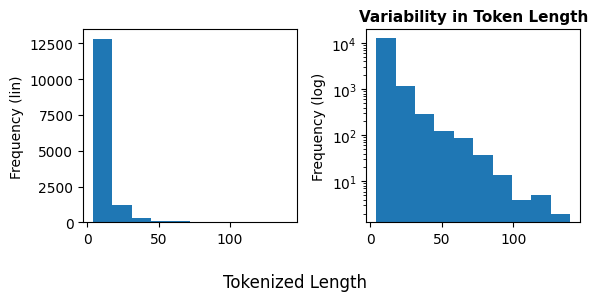

In [28]:
# display histogram of the frequency of tokenized length
fig, ax = plt.subplots(1, 2, figsize=(6,3))

### chart scaling
ax[1].set_yscale('log')

### data
ax[0].hist(tokens_len, label='Tokenized SMILEs Length')
ax[1].hist(tokens_len, label='Tokenized SMILEs Length')

### chart labels
plt.title(
    f'Variability in Token Length', 
    fontweight='bold', fontsize=11
)
fig.supxlabel('Tokenized Length')
ax[0].set_ylabel('Frequency (lin)')
ax[1].set_ylabel('Frequency (log)')

fig.tight_layout()
plt.show()

In [29]:
# filter dataframe by token length to avoid ???
filter_to_length = 20
logPdata_filtered = logPdata[logPdata['Tokenized Length'] < filter_to_length]

print('log(P) DataFrame shape after filtering: ', logPdata_filtered.shape)

log(P) DataFrame shape after filtering:  (13288, 4)


In [30]:
# split into training and testing datasets
split_data = train_test_split(
    logPdata_filtered, test_size=0.1, shuffle=True
    )

train, test = split_data[0], split_data[1]

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)

Training data shape:  (11959, 4)
Testing data shape:  (1329, 4)


#### 1.1 | Visualise SMILES

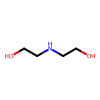

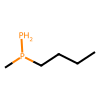

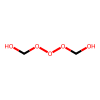

In [31]:
# create list of SMILES
SMILES_list = logPdata['SMILES'].values.tolist()

# create Mol objects from SMILES
ms = [Chem.MolFromSmiles(smi) for smi in SMILES_list[9:12]]   ### 'SMILES_list' sliced to visualise selected values only

# visualise Mol objects
for m in ms:
    img = Draw.MolToImage(m, size=(100,100))
    display(img)

# 2 | RNN (LSTM) Model

In [32]:
# format training data - descriptors
def format_descriptors(data:pd.DataFrame, max_token_len:int):
    '''
    ???
    '''
    # create blank numpy.array object of correct size
    X = np.zeros((len(data), max_token_len))

    # overwrite blank numpy.array with tokenised data
    # ensures length of all entries is standardised by padding with '0' values
    for i, token in zip(np.arange(0,len(data),1), data['Tokenize']):
        token_arr = np.asarray(token)
        X[i][:len(token_arr)] = token_arr

    # convert to torch.tensor object
    X = torch.tensor(X[:, :, None], dtype = torch.float32)

    print('Shape of Descriptor Data: ', X.shape)

    return X


# format training data - labels
def format_labels(data):
    '''
    ???
    '''
    # convert Clog(P) data to a torch.tensor object
    Y = np.asarray(data['ClogP'])
    Y = torch.tensor(Y[:, None], dtype=torch.float32)

    print('Shape of True Value Data: ', Y.shape)

    return Y

In [33]:
# format training and testing data
trainX = format_descriptors(train, filter_to_length)     ### training data descriptors
testX = format_descriptors(test, filter_to_length)     ### testing data descriptors

trainY_true = format_labels(train)     ### training data true Clog(P) values
testY_true = format_labels(test)     ### testing data true Clog(P) values

Shape of Descriptor Data:  torch.Size([11959, 20, 1])
Shape of Descriptor Data:  torch.Size([1329, 20, 1])
Shape of True Value Data:  torch.Size([11959, 1])
Shape of True Value Data:  torch.Size([1329, 1])


In [34]:
# define the NN model architecture
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        '''
        ???
        '''
        super(LSTMModel, self).__init__()

        # define internal variables
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        # ???
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)


    def forward(self, x, h0=None, c0=None):
        '''
        ???
        '''
        # ???
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        # ???
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out, hn, cn

In [56]:
NUM_EPOCHS = 500
HIDDEN_DIM = 100

In [57]:
# instantiate model, criterion, and optimizer ???
model = LSTMModel(input_dim=1, hidden_dim=HIDDEN_DIM, layer_dim=1, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [58]:
# ???
h0, c0 = None, None

# blank list to store loss values 
loss_by_epoch = list()

# ???
for epoch in range(NUM_EPOCHS):
    # switch to model training mode
    model.train()
    optimizer.zero_grad()

    outputs, h0, c0 = model(trainX, h0, c0)

    loss = criterion(outputs, trainY_true)
    loss.backward()

    optimizer.step()
    
    h0, c0 = h0.detach(), c0.detach()
    
    # add loss value to storage list
    loss_by_epoch.append(loss.item())

    # print every 5th loss value during model training
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss.item():.4f}')

Epoch [10/500], Loss: 1.5488
Epoch [20/500], Loss: 1.5025
Epoch [30/500], Loss: 1.4292
Epoch [40/500], Loss: 1.3733
Epoch [50/500], Loss: 1.3666
Epoch [60/500], Loss: 1.3342
Epoch [70/500], Loss: 1.2985
Epoch [80/500], Loss: 1.2538
Epoch [90/500], Loss: 1.2897
Epoch [100/500], Loss: 1.2768
Epoch [110/500], Loss: 1.2722
Epoch [120/500], Loss: 1.2484
Epoch [130/500], Loss: 1.2329
Epoch [140/500], Loss: 1.2045
Epoch [150/500], Loss: 1.2593
Epoch [160/500], Loss: 1.2258
Epoch [170/500], Loss: 1.1994
Epoch [180/500], Loss: 1.2004
Epoch [190/500], Loss: 1.2659
Epoch [200/500], Loss: 1.2947
Epoch [210/500], Loss: 1.2080
Epoch [220/500], Loss: 1.1477
Epoch [230/500], Loss: 1.1253
Epoch [240/500], Loss: 1.1086
Epoch [250/500], Loss: 1.0961
Epoch [260/500], Loss: 1.0684
Epoch [270/500], Loss: 1.0115
Epoch [280/500], Loss: 0.8840
Epoch [290/500], Loss: 0.7935
Epoch [300/500], Loss: 0.8483
Epoch [310/500], Loss: 0.8063
Epoch [320/500], Loss: 0.8057
Epoch [330/500], Loss: 0.7925
Epoch [340/500], Lo

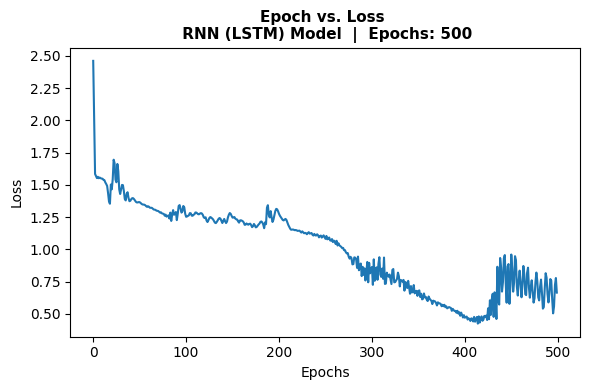

In [59]:
# plot loss values per epoch
fig, ax = plt.subplots(1, 1, figsize=(6,4))

### enumerate epochs
x_vals = range(0, len(loss_by_epoch), 1)

### data
ax.plot(x_vals, loss_by_epoch)

### chart labels
plt.title(
    f'Epoch vs. Loss \n RNN (LSTM) Model  |  Epochs: {NUM_EPOCHS:.0f}', 
    fontweight='bold', fontsize=11
)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

fig.tight_layout()
plt.show()

In [60]:
# switch to model evaluation mode
model.eval()

# ???
trainY_pred, _, _ = model(trainX, h0, c0)

trainY_pred_arr = trainY_pred.detach().numpy()#.reshape(1, 11959)
train_error = trainY_pred-trainY_true
train_error = train_error.detach().numpy()

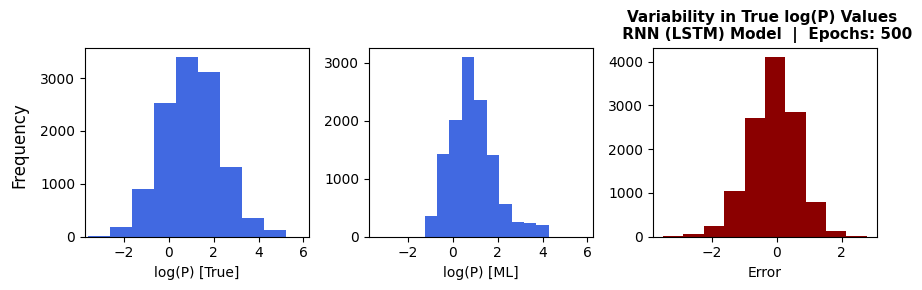

In [61]:
# display histogram of the frequency of true values
fig, ax = plt.subplots(1, 3, figsize=(9,3))

### data
ax[0].hist(trainY_true, label='LogP (True)', color='royalblue')
ax[1].hist(trainY_pred_arr, label='LogP (ML)', color='royalblue')
ax[2].hist(train_error, label='Error', color='darkred')

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)

### chart labels
fig.supylabel('Frequency')
plt.title(
    f'Variability in True log(P) Values \n RNN (LSTM) Model  |  Epochs: {NUM_EPOCHS:.0f}', 
    fontweight='bold', fontsize=11
)
ax[0].set_xlabel('log(P) [True]')
ax[1].set_xlabel('log(P) [ML]')
ax[2].set_xlabel('Error')

fig.tight_layout()
plt.show()

In [62]:
model.eval()
testY_pred, _, _ = model(testX, None, None)

testY_pred_arr = testY_pred.detach().numpy()#.reshape(1, 11959)
test_error = testY_pred-testY_true
test_error = test_error.detach().numpy()

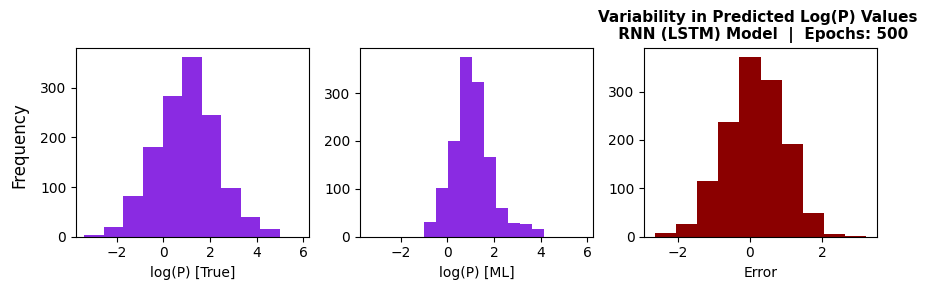

In [63]:
# display histogram of the frequency of true values
fig, ax = plt.subplots(1, 3, figsize=(9,3))

### data
ax[0].hist(testY_true, label='LogP (True)', color='blueviolet')
ax[1].hist(testY_pred_arr, label='LogP (ML)', color='blueviolet')
ax[2].hist(test_error, label='Error', color='darkred')

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)

### chart labels
fig.supylabel('Frequency')
plt.title(
    f'Variability in Predicted Log(P) Values \n RNN (LSTM) Model  |  Epochs: {NUM_EPOCHS:.0f}', 
    fontweight='bold', fontsize=11
)
ax[0].set_xlabel('log(P) [True]')
ax[1].set_xlabel('log(P) [ML]')
ax[2].set_xlabel('Error')

fig.tight_layout()
plt.show()

In [64]:
# add predicted values and error from true values to log(P) DataFrame 
    # for training and testing data
train['ClogP (Predicted)'] = trainY_pred_arr
train['Error'] = train_error

test['ClogP (Predicted)'] = testY_pred_arr
test['Error'] = test_error

In [65]:
# calculate root mean square error for training and testing data
rmse_train = np.sqrt(
    mean_squared_error(train['ClogP'], train['ClogP (Predicted)'])
)

rmse_test = np.sqrt(
    mean_squared_error(test['ClogP'], test['ClogP (Predicted)'])
)

print(f'Training RMSE: {rmse_train:.5f}')
print(f'Testing RMSE: {rmse_test:.5f}')

Training RMSE: 0.74954
Testing RMSE: 0.81687


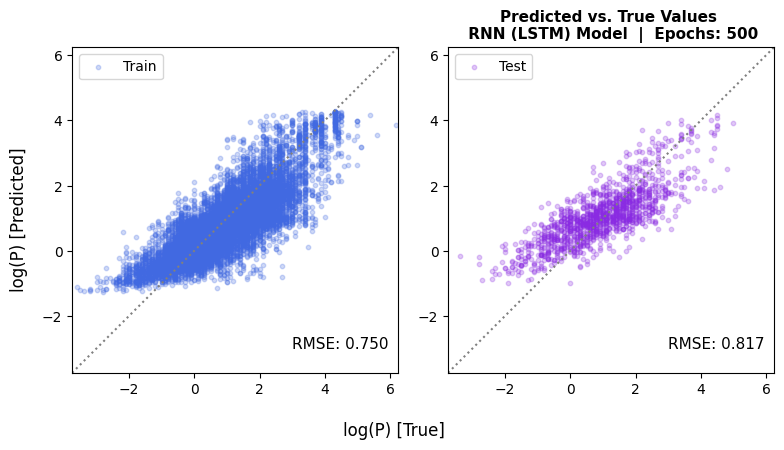

In [66]:
# plot true vs. predicted log(P) values for training and testing data 
fig, ax = plt.subplots(1, 2, figsize=(8,4.5))

### data
ax[0].scatter(train['ClogP'], train['ClogP (Predicted)'], c='royalblue', s=10, alpha=0.25, label='Train')
ax[1].scatter(test['ClogP'], test['ClogP (Predicted)'], c='blueviolet', s=10, alpha=0.25, label='Test')

### ideal fit
ax[0].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":")
ax[1].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":")

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[0].set_ylim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)
ax[1].set_ylim(-3.75, 6.25)

### legends
ax[0].legend()
ax[1].legend()

### chart labels
fig.supxlabel('log(P) [True]')
fig.supylabel('log(P) [Predicted]')
plt.title(
    f'Predicted vs. True Values \n RNN (LSTM) Model  |  Epochs: {NUM_EPOCHS:.0f}', 
    fontweight='bold', fontsize=11
)

### annotate with RMSEs
ax[0].annotate(f'RMSE: {rmse_train:.3f}', xy=(3,-3), fontsize=11)
ax[1].annotate(f'RMSE: {rmse_test:.3f}', xy=(3,-3), fontsize=11)

fig.tight_layout()
plt.show()

In [45]:
import time

list_of_epoch_numbers = [
    100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 
    100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 
    #500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500,
    #500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500,
    #650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 
    #650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 650, 
    #1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 
    #1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 
    #1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 
    #1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200,
    #1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 
    #2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000
    #250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 
    #250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 
    #400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 
    #400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 
]

len(list_of_epoch_numbers)

50

In [46]:
rmse_all = list()
time_all = list()
n = 1

for i in list_of_epoch_numbers:
    
    print(f'----------------- {n} ({i} epochs) -----------------')
    start = time.time()
    
    logPdata_filtered_COPY = deepcopy(logPdata_filtered)
    # split into training and testing datasets
    split_data = train_test_split(
        logPdata_filtered_COPY, test_size=0.1, shuffle=True
        )

    train, test = split_data[0], split_data[1]

    print('Training data shape: ', train.shape)
    print('Testing data shape: ', test.shape)

    # ---------------------------------------------------------------------------------------

    # format training and testing data
    trainX = format_descriptors(train, filter_to_length)     ### training data descriptors
    testX = format_descriptors(test, filter_to_length)     ### testing data descriptors

    trainY_true = format_labels(train)     ### training data true Clog(P) values
    testY_true = format_labels(test)     ### testing data true Clog(P) values

    # ---------------------------------------------------------------------------------------

    # instantiate model, criterion, and optimizer ???
    model = LSTMModel(input_dim=1, hidden_dim=100, layer_dim=1, output_dim=1)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # ---------------------------------------------------------------------------------------

    # ???
    num_epochs = i
    h0, c0 = None, None

    # blank list to store loss values 
    loss_by_epoch = list()

    # ???
    for epoch in range(num_epochs):
        
        # switch to model training mode
        model.train()
        optimizer.zero_grad()

        outputs, h0, c0 = model(trainX, h0, c0)

        loss = criterion(outputs, trainY_true)
        loss.backward()

        optimizer.step()
        
        h0, c0 = h0.detach(), c0.detach()
        
        # add loss value to storage list
        loss_by_epoch.append(loss.item())

        # print every 5th loss value during model training
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    # ---------------------------------------------------------------------------------------

    # switch to model evaluation mode
    model.eval()

    # ???
    trainY_pred, _, _ = model(trainX, h0, c0)

    trainY_pred_arr = trainY_pred.detach().numpy()#.reshape(1, 11959)
    train_error = trainY_pred-trainY_true
    train_error = train_error.detach().numpy()

    # ---------------------------------------------------------------------------------------

    model.eval()
    testY_pred, _, _ = model(testX, None, None)

    testY_pred_arr = testY_pred.detach().numpy()#.reshape(1, 11959)
    test_error = testY_pred-testY_true
    test_error = test_error.detach().numpy()

    # ---------------------------------------------------------------------------------------

    # add predicted values and error from true values to log(P) DataFrame 
        # for training and testing data
    train['ClogP (Predicted)'] = trainY_pred_arr
    train['Error'] = train_error

    test['ClogP (Predicted)'] = testY_pred_arr
    test['Error'] = test_error

    # ---------------------------------------------------------------------------------------

    # calculate root mean square error for training and testing data
    rmse_train = np.sqrt(
        mean_squared_error(train['ClogP'], train['ClogP (Predicted)'])
    )

    rmse_test = np.sqrt(
        mean_squared_error(test['ClogP'], test['ClogP (Predicted)'])
    )

    print(f'Training RMSE: {rmse_train:.5f}')
    print(f'Testing RMSE: {rmse_test:.5f}')

    rmse_all.append([rmse_train, rmse_test])
    
    end = time.time()
    print('Elapsed Time: ', end - start)
    time_all.append(end-start)

    n+=1

----------------- 1 (100 epochs) -----------------
Training data shape:  (11959, 4)
Testing data shape:  (1329, 4)
Shape of Descriptor Data:  torch.Size([11959, 20, 1])
Shape of Descriptor Data:  torch.Size([1329, 20, 1])
Shape of True Value Data:  torch.Size([11959, 1])
Shape of True Value Data:  torch.Size([1329, 1])
Epoch [100/100], Loss: 1.4925
Training RMSE: 1.16938
Testing RMSE: 1.18764
Elapsed Time:  45.31303548812866
----------------- 2 (100 epochs) -----------------
Training data shape:  (11959, 4)
Testing data shape:  (1329, 4)
Shape of Descriptor Data:  torch.Size([11959, 20, 1])
Shape of Descriptor Data:  torch.Size([1329, 20, 1])
Shape of True Value Data:  torch.Size([11959, 1])
Shape of True Value Data:  torch.Size([1329, 1])
Epoch [100/100], Loss: 1.5720
Training RMSE: 1.25283
Testing RMSE: 1.22478
Elapsed Time:  46.046715259552
----------------- 3 (100 epochs) -----------------
Training data shape:  (11959, 4)
Testing data shape:  (1329, 4)
Shape of Descriptor Data:  to

KeyboardInterrupt: 

In [ ]:
print(rmse_all)

[[np.float64(0.694330905949412), np.float64(0.799181799626094)], [np.float64(1.0040383312694228), np.float64(1.1834503955599884)], [np.float64(0.9373827999818043), np.float64(0.9683427938840609)], [np.float64(0.9535077968813083), np.float64(1.058682292689953)], [np.float64(0.860499963027023), np.float64(0.9780418831771317)], [np.float64(0.7850009493538829), np.float64(0.8511169919887633)], [np.float64(0.9234713729340345), np.float64(0.8958075602015568)], [np.float64(1.119757143236448), np.float64(1.1429002312541798)], [np.float64(0.909021328004765), np.float64(0.9834962704344257)], [np.float64(0.8268246561400178), np.float64(0.8482183533886334)], [np.float64(0.8023889598102607), np.float64(0.8984812617832789)], [np.float64(0.747477715902227), np.float64(0.8258392944635525)], [np.float64(0.7705314546870494), np.float64(1.0195978696430126)], [np.float64(0.9635068101076686), np.float64(1.3130809856594345)], [np.float64(0.7745875212109936), np.float64(0.9207363558854026)], [np.float64(0.71

In [ ]:
print(time_all)

[162.8726944923401, 150.72759675979614, 157.04965615272522, 153.6383421421051, 152.22874188423157, 165.43084025382996, 189.34942054748535, 196.98474287986755, 190.10061264038086, 194.5974841117859, 194.18866801261902, 192.9730315208435, 186.6724545955658, 192.93288254737854, 195.81864166259766, 191.56806087493896, 190.86033940315247, 194.38705444335938, 193.7178075313568, 191.76923036575317, 192.8652777671814, 193.66172623634338, 196.28804302215576, 196.83115530014038, 191.2025022506714, 196.48739290237427, 196.14402103424072, 191.41463041305542, 191.9428482055664, 194.83699941635132, 192.52503037452698, 173.4397509098053, 195.79996752738953, 191.22849941253662, 192.09371042251587, 193.2582824230194, 194.85917806625366, 190.31368160247803, 190.2524609565735, 194.04217720031738, 193.33855628967285, 193.54178428649902, 195.62239718437195, 193.58535814285278, 194.7835817337036, 51959.31311368942, 175.63401627540588, 158.6587269306183, 167.08306431770325, 178.30927562713623]


In [ ]:
#rmse_100 = rmse_all[:50]
#time_100 = time_all[:50]

#rmse_1000 = rmse_all[:50]
#time_1000 = time_all[:50]

#rmse_500 = rmse_all[:50]
#time_500 = time_all[:50]

#rmse_650 = rmse_all[:50]
#time_650 = time_all[:50]

#rmse_1500 = rmse_all[:10]
#time_1500 = time_all[:10]

#rmse_2000 = rmse_all[10:]
#time_2000 = time_all[10:]

#rmse_250 = rmse_all[:50]
#time_250 = time_all[:50]

rmse_400 = rmse_all[:50]
time_400 = time_all[:49]


print(
    len(rmse_400), 
    len(time_400),
)

50 49


In [ ]:
#rmse_100_arr = np.array((rmse_100))
#time_100_arr = np.array((time_100))

#rmse_1000_arr = np.array((rmse_1000))
#time_1000_arr = np.array((time_1000))

#rmse_500_arr = np.array((rmse_500))
#time_500_arr = np.array((time_500))

#rmse_650_arr = np.array((rmse_650))
#time_650_arr = np.array((time_650))

#rmse_1500_arr = np.array((rmse_1500))
#time_1500_arr = np.array((time_1500))

#rmse_2000_arr = np.array((rmse_2000))
#time_2000_arr = np.array((time_2000))

#rmse_250_arr = np.array((rmse_250))
#time_250_arr = np.array((time_250))

rmse_400_arr = np.array((rmse_400))
time_400_arr = np.array((time_400))

In [ ]:
print( np.quantile(rmse_100_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_100_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_100_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

print( np.quantile(rmse_1000_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_1000_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_1000_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

print( np.quantile(rmse_500_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_500_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_500_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

print( np.quantile(rmse_650_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_650_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_650_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

print( np.quantile(rmse_1500_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_1500_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_1500_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

print( np.quantile(rmse_2000_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_2000_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_2000_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

print( np.quantile(rmse_250_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_250_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_250_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

print( np.quantile(rmse_400_arr.T[0], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(rmse_400_arr.T[1], [0, 0.25, 0.5, 0.75, 1]) )
print( np.quantile(time_400_arr,      [0, 0.25, 0.5, 0.75, 1]) )
print('')

[1.11561173 1.18447327 1.22607126 1.24466991 1.26569526]
[1.07630242 1.20159092 1.23779846 1.26150502 1.34934379]
[36.89672375 37.74156797 39.42222369 45.7459929  48.68953657]

[0.25753317 0.44680969 0.47416731 0.52701618 0.64192991]
[0.61550761 0.72410973 0.85331243 0.94203826 1.22497033]
[ 362.91501045  385.68413174  416.90803874  465.22010416 5857.95572042]

[0.53965552 0.61944279 0.73135417 0.81494051 1.06167697]
[0.63665757 0.74627112 0.87752525 0.99830612 1.31916294]
[180.58016634 214.20391339 235.09622073 237.27482635 246.075032  ]

[0.48133393 0.56138004 0.61700638 0.67388486 0.95875335]
[0.58894847 0.78107292 0.88444972 1.01193493 1.7057787 ]
[234.45493412 270.10053635 306.99490976 309.98812991 320.23891759]

[0.32906809 0.34225249 0.36937883 0.43657611 0.46696294]
[0.65738251 0.74103826 0.84486163 1.00445789 1.05071227]
[561.93088436 573.5969063  610.7806505  712.03274781 742.81735992]

[0.0660423  0.14554427 0.17479436 0.20939813 0.31790683]
[0.57711506 0.72209946 0.85624029

In [ ]:
t1000 = list( deepcopy(time_1000) )
t1000.sort()
t1000

[362.9150104522705,
 364.3573753833771,
 370.3038558959961,
 374.059574842453,
 374.9295678138733,
 375.298353433609,
 376.27207374572754,
 376.79951548576355,
 377.00864601135254,
 377.32246589660645,
 377.3510296344757,
 383.76228070259094,
 384.534232378006,
 389.133829832077,
 389.8961672782898,
 390.8044259548187,
 391.4326274394989,
 393.34440755844116,
 398.80403304100037,
 399.08207273483276,
 401.8018834590912,
 405.793035030365,
 412.7712471485138,
 414.65632247924805,
 415.745174407959,
 418.07090306282043,
 432.2213819026947,
 434.50643968582153,
 438.47967982292175,
 443.107848405838,
 445.55874609947205,
 452.17225432395935,
 452.8514542579651,
 456.8840506076813,
 463.8705105781555,
 464.22120332717896,
 464.61337900161743,
 465.4223458766937,
 466.8630394935608,
 469.982253074646,
 479.0541889667511,
 480.2590854167938,
 481.06026697158813,
 481.5235505104065,
 482.76467084884644,
 482.95643186569214,
 485.8314461708069,
 492.49439692497253,
 1842.4805142879486,
 5857.9

In [ ]:
print( np.quantile(t1000[:48],      [0, 0.25, 0.5, 0.75, 1]) )

[362.91501045 384.34124446 415.20074844 464.31924725 492.49439692]


1.2656952647712416 1.1156117307716946 1.2118212372517092
[1.11561173 1.18447327 1.22607126 1.24466991 1.26569526]


(array([ 2.,  2.,  1.,  5.,  8.,  2.,  3.,  6., 15.,  6.]),
 array([1.11561173, 1.13062008, 1.14562844, 1.16063679, 1.17564514,
        1.1906535 , 1.20566185, 1.2206702 , 1.23567856, 1.25068691,
        1.26569526]),
 <BarContainer object of 10 artists>)

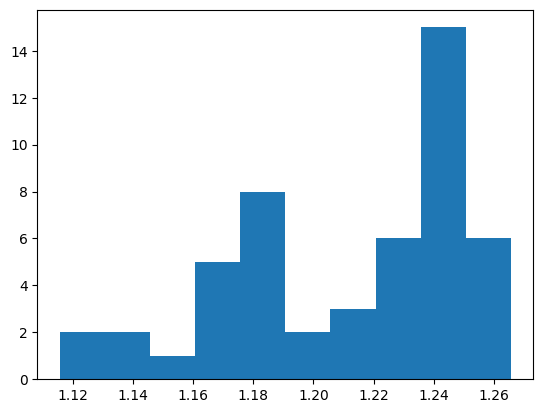

In [ ]:
print(
    max(rmse_100_arr.T[0]), min(rmse_100_arr.T[0]), sum(rmse_100_arr.T[0])/50
)

print(np.quantile(rmse_100_arr.T[0], [0, 0.25, 0.5, 0.75, 1]))

plt.hist(rmse_100_arr.T[0])

1.3493437907953751 1.0763024220121769 1.2340182583120656


(array([ 1.,  0.,  5.,  3.,  8., 10., 13.,  4.,  3.,  3.]),
 array([1.07630242, 1.10360656, 1.1309107 , 1.15821483, 1.18551897,
        1.21282311, 1.24012724, 1.26743138, 1.29473552, 1.32203965,
        1.34934379]),
 <BarContainer object of 10 artists>)

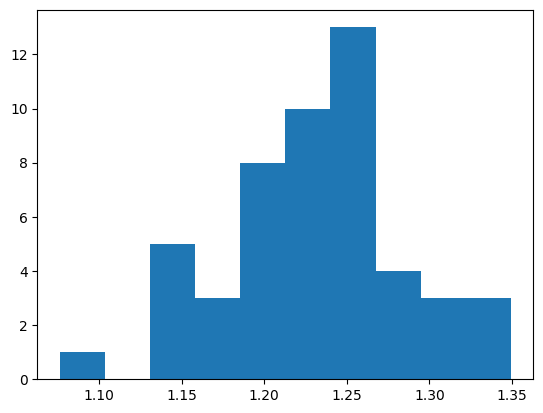

In [ ]:
print(
    max(rmse_100_arr.T[1]), min(rmse_100_arr.T[1]), sum(rmse_100_arr.T[1])/50
)

plt.hist(rmse_100_arr.T[1])

(array([ 8.,  8., 11., 13.,  4.,  2.,  1.,  2.,  0.,  1.]),
 array([0.58894847, 0.70063149, 0.81231452, 0.92399754, 1.03568056,
        1.14736359, 1.25904661, 1.37072963, 1.48241266, 1.59409568,
        1.7057787 ]),
 <BarContainer object of 10 artists>)

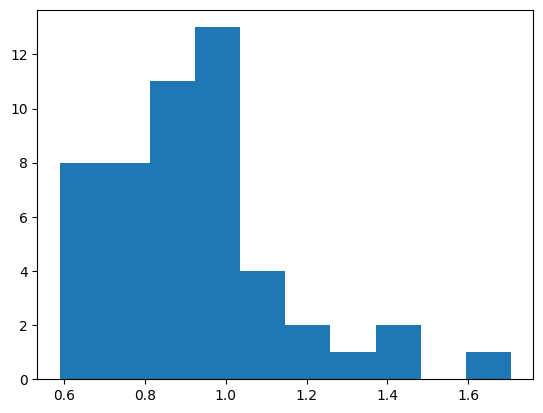

In [ ]:
plt.hist(rmse_650_arr.T[1])

In [ ]:
q100_train = [1.11561173, 1.18447327, 1.22607126, 1.24466991, 1.26569526]
q100_test =  [1.07630242, 1.20159092, 1.23779846, 1.26150502, 1.34934379]
q100_time =  [36.89672375, 37.74156797, 39.42222369, 45.7459929, 48.68953657]

q500_train = [0.53965552, 0.61944279, 0.73135417, 0.81494051, 1.06167697]
q500_test =  [0.63665757, 0.74627112, 0.87752525, 0.99830612, 1.31916294]
q500_time =  [180.58016634, 214.20391339, 235.09622073, 237.27482635, 246.075032]

q650_train = [0.48133393, 0.56138004, 0.61700638, 0.67388486, 0.95875335]
q650_test =  [0.58894847, 0.78107292, 0.88444972, 1.01193493, 1.7057787 ]
# is there an outlier in the above test data?
#q650_test_outliers = ?
q650_time =  [234.45493412, 270.10053635, 306.99490976, 309.98812991, 320.23891759]

q1000_train = [0.25753317, 0.44680969, 0.47416731, 0.52701618, 0.64192991]
q1000_test =  [0.61550761, 0.72410973, 0.85331243, 0.94203826, 1.22497033]
q1000_time =  [362.91501045, 384.34124446, 415.20074844, 464.31924725, 492.49439692]
q1000_time_outliers = [1842.4805142879486, 5857.95572042]

q1500_train = [0.32906809, 0.34225249, 0.36937883, 0.43657611, 0.46696294]
q1500_test =  [0.65738251, 0.74103826, 0.84486163, 1.00445789, 1.05071227]
q1500_time =  [561.93088436, 573.5969063, 610.7806505, 712.03274781, 742.81735992]

q2000_train = [0.0660423, 0.14554427, 0.17479436, 0.20939813, 0.31790683]
q2000_test =  [0.57711506, 0.72209946, 0.85624029, 0.95205855, 0.99392066]
q2000_time =  [955.60021615, 959.67902851, 963.35460162, 968.46209687, 975.96795917]

q250_train = [0.85658869, 0.99914852, 1.05725661, 1.10685928, 1.25066015]
q250_test =  [0.85778855, 1.03790831, 1.10991846, 1.17855669, 1.52017834]
q250_time =  [92.55049181, 113.62932998, 120.03903389, 121.85344809, 125.12633038]

q400_train = [0.64198882, 0.76497233, 0.81614158, 0.93390494, 1.11975714]
q400_test = [0.6621309, 0.84860392, 0.91619554, 1.02655831, 1.31308099]
q400_time = [150.72759676, 189.34942055, 192.52503037, 194.38705444, 196.98474288]
q400_time_outliers = [51959.31311369]

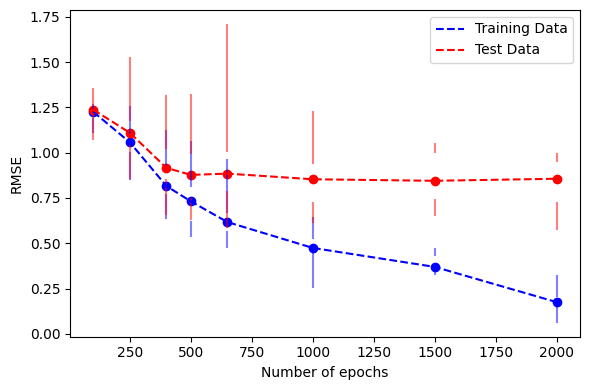

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

y1 = [q100_train, q250_train, q400_train, q500_train, q650_train, q1000_train, q1500_train, q2000_train]
y2 = [q100_test, q250_test, q400_test, q500_test, q650_test, q1000_test, q1500_test, q2000_test]
x = [100, 250, 400, 500, 650, 1000, 1500, 2000]

for epochs, quantiles1, quantiles2 in zip(x, y1, y2):
    ax.scatter([epochs], [quantiles1[2]], c='blue', alpha=1)
    ax.plot([epochs, epochs], [quantiles1[0], quantiles1[1]], c='blue', alpha=0.5)
    ax.plot([epochs, epochs], [quantiles1[3], quantiles1[4]], c='blue', alpha=0.5)

    ax.scatter([epochs], [quantiles2[2]], c='red', alpha=1)
    ax.plot([epochs, epochs], [quantiles2[0], quantiles2[1]], c='red', alpha=0.5)
    ax.plot([epochs, epochs], [quantiles2[3], quantiles2[4]], c='red', alpha=0.5)

ax.plot(
    [100, 250, 400, 500, 650, 1000, 1500, 2000],
    [q100_train[2], q250_train[2], q400_train[2], q500_train[2], q650_train[2], q1000_train[2], q1500_train[2], q2000_train[2]],
    c='blue', linestyle='--', label='Training Data'
)

ax.plot(
    [100, 250, 400, 500, 650, 1000, 1500, 2000],
    [q100_test[2], q250_test[2], q400_test[2], q500_test[2], q650_test[2], q1000_test[2], q1500_test[2], q2000_test[2]],
    c='red', linestyle='--', label='Test Data'
)

ax.set_xlabel('Number of epochs')
ax.set_ylabel('RMSE')
ax.legend()

fig.tight_layout()

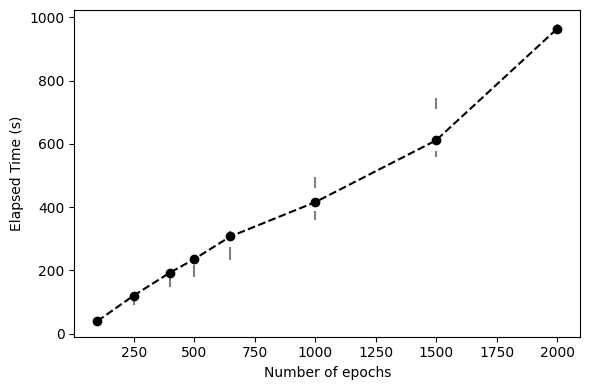

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

y = [q100_time, q250_time, q400_time, q500_time, q650_time, q1000_time, q1500_time, q2000_time]
x = [100, 250, 400, 500, 650, 1000, 1500, 2000]

for epochs, quantiles in zip(x, y):
    ax.scatter([epochs], [quantiles[2]], c='black', alpha=1)
    ax.plot([epochs, epochs], [quantiles[0], quantiles[1]], c='black', alpha=0.5)
    ax.plot([epochs, epochs], [quantiles[3], quantiles[4]], c='black', alpha=0.5)

ax.plot(
    [100, 250, 400, 500, 650, 1000, 1500, 2000],
    [q100_time[2], q250_time[2], q400_time[2], q500_time[2], q650_time[2], q1000_time[2], q1500_time[2], q2000_time[2]],
    c='black', linestyle='--', label='Elapsed Time'
)

#ax.scatter(
#    [1000, 1000],
#    q1000_time_outliers,
#    c='black', marker='x'
#)

ax.set_xlabel('Number of epochs')
ax.set_ylabel('Elapsed Time (s)')
#ax.legend()

fig.tight_layout()